# sgRNA mapping

In [182]:
import scanpy as sc
import scipy.io
import pandas as pd
import gzip
import os
import anndata
dir = '/wynton/group/pollen/jding/brainchromatin/pipseq/dragen/LMO1'
adatas = []
for name in ['LMO1']:
    matrix_file = os.path.join(dir,name + ".scRNA.filtered.matrix.mtx.gz")
    features_file = os.path.join(dir, name + ".scRNA.filtered.features.tsv.gz")
    meta_file = os.path.join(dir,name +  ".scRNA.filtered.barcodes.tsv.gz")
    with gzip.open(matrix_file, 'rb') as f:
        X = scipy.io.mmread(f).tocsc()
    features = pd.read_csv(features_file, sep='\t', header=None, index_col = 1)
    meta = pd.read_csv(meta_file, sep='\t', index_col = 0, header=None)
    adata = anndata.AnnData(X.transpose(), obs=meta, var=features)
    adata.var.index.name = "gene_name"
    adata.var.columns = ['gene_id', 'feature_type']
    adata.obs['batch'] = name
    adata.obs['pip-barcode'] = adata.obs_names
    adata.obs.index.name = "cell_id"
    adata.obs_names_make_unique()
    adata.var_names_make_unique()
    adatas.append(adata)

/tmp/ipykernel_590138/2293774418.py:17: FutureWarning: X.dtype being converted to np.float32 from int64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = anndata.AnnData(X.transpose(), obs=meta, var=features)
/wynton/home/pollenlab/jding/miniconda3/envs/scvi-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [184]:
adata = adata[:,adata.var['feature_type'] == 'CRISPR Direct Capture']

In [ ]:
adata = adata[:,adata.var['feature_type'] == 'Gene Expression']

In [188]:
#rename cells using 10x cellbarcode
barcodes = pd.read_csv('/wynton/group/pollen/jding/brainchromatin/HM2D/cellranger-7.2.0/HM2D_3rd_L1/outs/filtered_feature_bc_matrix/barcodes.tsv.gz', sep='\t',  header=None, index_col=0).rename_axis('barcode')
adata.obs.index = barcodes.index[:len(adata.obs_names)].values

In [82]:
import os
import gzip
import pandas as pd
from scipy.io import mmwrite
from scipy.sparse import issparse

# Set output directory
output_dir = "/wynton/scratch/jding/Cellbouncer/CTRL/"
#output_dir = "/wynton/scratch/jding/Cellbouncer/LMO1/"
os.makedirs(output_dir, exist_ok=True)

matrix_path = os.path.join(output_dir, "matrix.mtx.gz")
with gzip.open(matrix_path, "wb") as f:
    mmwrite(f, adata.X if issparse(adata.X) else adata.X.tocsr())

# 2. Write barcodes.tsv.gz
barcodes_path = os.path.join(output_dir, "barcodes.tsv.gz")
barcodes = adata.obs_names
barcodes.to_series().to_csv(barcodes_path, index=False, header=False)

# 3. Write features.tsv.gz
features_path = os.path.join(output_dir, "features.tsv.gz")
if "gene_id" in adata.var.columns:
    feature_ids = adata.var["gene_id"]
else:
    feature_ids = adata.var_names

if "gene_name" in adata.var.columns:
    gene_symbols = adata.var["gene_name"]
else:
    gene_symbols = adata.var_names

# Create a DataFrame with 3 columns as expected by 10x Genomics
features_df = pd.DataFrame({
    "gene_id": feature_ids,
    "gene_name": gene_symbols,
    "feature_type": ["CRISPR Guide Capture"] * adata.shape[1]
})
features_df.to_csv(features_path, sep="\t", index=False, header=False)

print("Export complete.")

Export complete.


In [190]:
sgRNA_dir = '/wynton/group/pollen/jding/brainchromatin/pipseq/cellbouncer/'
f = 'LMO1'
#Add guide assignment
df= pd.read_csv(os.path.join(sgRNA_dir,f+'.assignments'),sep='\t',index_col=0,header=None)
df.columns = ["sgRNA_NKS", "num_guide_IDs",'log']
df.index =[x+'-1' for x in df.index]
for x in df.columns:
    adata.obs[x] = df[x] 

/tmp/ipykernel_590138/1628894787.py:8: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[x] = df[x]


In [226]:
df= pd.read_csv('/wynton/scratch/jding/LMO1/feature/barcoded_fastqs/Results/read_count/LMO1.assignments',sep='\t',index_col=0,header=None)
df.columns = ["sgRNA_NKS", "num_guide_IDs",'log']
df.head()

,sgRNA_NKS,num_guide_IDs,log
0,,,
AAATACCATCTTTTGT,WT,0,0.000000
AAACTGTGATTCCATT,"ARX_+_25034044.23-P1-GCTTGTCCTGAGCGCGGAGA,ARX_...",5,96.444563
AACAAGCGAGCCAGTT,WT,0,0.000000
AAAATCGGTCAGCTAA,unmapped,1,4.983012
AAAGCAACCAAGCCTT,unmapped,1,13.691106


# Gene expression

In [ ]:
import numpy as np
ribo_genes=[name for name in adata.var_names if name.startswith('RPS') or name.startswith('RPL') ]
adata.obs['percent_ribo'] = np.sum(
adata[:, ribo_genes].X, axis=1) / np.sum(adata.X, axis=1)
mito_genes = [name for name in adata.var_names if name in ['ND1','ND2','ND4L','ND4','ND5','ND6','ATP6','ATP8','CYTB','COX1','COX2','COX3'] or name.startswith('CHRM-') or name.startswith('MT-')]
adata.obs['percent_mito'] = np.sum(
adata[:, adata.var.index.isin(mito_genes)].X, axis=1) / np.sum(adata.X, axis=1)
print(adata)

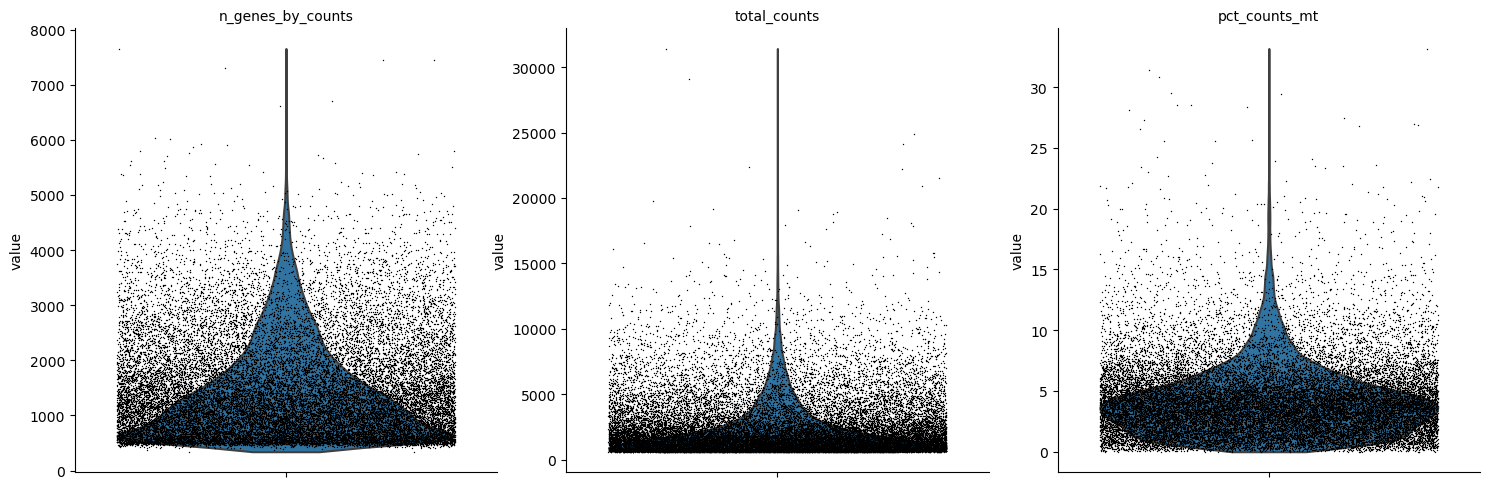

In [151]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

In [152]:
adata._inplace_subset_obs(adata.obs['percent_ribo']<.4)
adata._inplace_subset_obs(adata.obs['percent_mito']<.15)
adata._inplace_subset_var(~adata.var.index.isin(mito_genes))
adata

AnnData object with n_obs × n_vars = 27659 × 40394
    obs: 'batch', 'pip-barcode', 'sgRNA_NKS', 'num_guide_IDs', 'log', 'gene_NKS', 'num_gene_NKS', 'sgRNA', 'num_sgRNA', 'sgRNA_effecitve', 'percent_ribo', 'percent_mito', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_id', 'feature_type', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [153]:
#adata.raw = adata
#sc.pp.filter_genes(adata,min_cells=10)
sc.pp.filter_cells(adata, min_genes=500)
adata.raw = adata
adata

AnnData object with n_obs × n_vars = 26462 × 40394
    obs: 'batch', 'pip-barcode', 'sgRNA_NKS', 'num_guide_IDs', 'log', 'gene_NKS', 'num_gene_NKS', 'sgRNA', 'num_sgRNA', 'sgRNA_effecitve', 'percent_ribo', 'percent_mito', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_id', 'feature_type', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [154]:
adata.obs['gene_NKS'] = [','.join(list(set([i.split('_')[0] for i in x.split(',')]))) for x in adata.obs['sgRNA_NKS'].astype(str)]
adata.obs['num_gene_NKS'] = [len(list(set([i.split('_')[0] for i in x.split(',')]))) for x in adata.obs['sgRNA_NKS'].astype(str)]
#adata = adata[adata.obs['num_gene_NKS'].isin([1,2])]
adata.obs['gene_NKS'] =[x.replace('non-targeting,','') for x in adata.obs['gene_NKS']] 
adata.obs['gene_NKS'] =[x.replace(',non-targeting','') for x in adata.obs['gene_NKS']] 

In [ ]:
feature_ref = pd.read_csv('/wynton/home/pollenlab/jding/BrainChromatin/pipseq/feature_ref-illumina.csv',index_col=0)
feature_ref['guide_name'] = feature_ref.index
dic = dict(map(lambda i,j : (i,j) , feature_ref['name'], feature_ref['guide_name']))
dic

In [ ]:
adata.obs['sgRNA'] = [','.join(list(set([dic[i] if i in dic.keys() else i for i in x.split(',')]))) for x in adata.obs['sgRNA_NKS'].astype(str)]
adata.obs['num_sgRNA'] = [len(list(set(x.split(',')))) for x in adata.obs['sgRNA'].astype(str)]
adata.obs['sgRNA_effecitve'] = [','.join(list(set(i for i in x.split(',') if not 'Non-Targeting' in i))) for x in adata.obs['sgRNA'].astype(str)]

In [157]:
adata.obs['sgRNA_effecitve'].value_counts().head(30)

nan    26462
Name: sgRNA_effecitve, dtype: int64

In [159]:
adata.obs['sgRNA_NKS'] = adata.obs['sgRNA_NKS'].astype(str)
adata.write('/wynton/group/pollen/jding/brainchromatin/pipseq/dragen/LMO1/LMO1.h5ad')

LMO1:
donor0:GW16#196-M
donor1:GW19#139-M
donor2:GW17#187-M
donor3:GW21#154-F

In [ ]:
#Add individual demux
import scanpy as sc
import pandas as pd
import os
#adata = sc.read('/wynton/group/pollen/jding/brainchromatin/pipseq/dragen/LMO1/LMO1.h5ad')
adata.obs_names = adata.obs['pip-barcode'].values

vireo_dir=os.path.join('/wynton/scratch/jding/Vireo/')
df= pd.read_csv(os.path.join(vireo_dir,'LMO1','donor_ids.tsv'),sep='\t',index_col=0)
df['individual'] = ['GW16#196-M' if id == 'donor0' else 'GW19#139-M' if id == 'donor1' 
                    else 'GW17#187-M' if id == 'donor2' else 'GW21#154-F' if id == 'donor3' 
                    else id for id in df['donor_id']]
adata.obs['individual'] = df['individual']
adata.obs['stage'] = [x.split('#')[0] for x in adata.obs['individual'].to_list()]
adata.obs['sex'] = [x.split('-')[1] for x in adata.obs['individual'].to_list()]
adata = adata[adata.obs['individual'].isin(['GW16#196-M', 'GW17#187-M', 'GW19#139-M' , 'GW21#154-F'])]
adata.obs['individual'].value_counts()

In [ ]:
adata.raw = adata.copy()
sc.pp.normalize_total(adata,exclude_highly_expressed=True)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.scale(adata,max_value=10)
sc.pp.pca(adata,n_comps=100)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata)